In [22]:
%matplotlib inline 
import matplotlib.pyplot as plt

import IPython.display as ipd

import os
# os.chdir('/engram/nklab/hossein/recurrent_models/algonauts2025/subs_multimodal_encoder/')
os.chdir('/engram/nklab/pf2477/multimodal_encoder/')
!pwd

root_data_dir = '/engram/nklab/datasets/'

: 

In [23]:
class args_struc():
    def __init__(self):
        self.image_size = 224
        self.data_dir = '/engram/nklab/hossein/recurrent_models/algonauts2025/'
        self.sub = 1
        self.batch_size = 1
        self.backbone_arch = 'dinov2_q'
        self.modality = 'visual audio text'
        self.distributed = 0
        self.num_workers = 0
        self.val_split = 's05e'
        self.num_frames = 20
        self.objective = None
        self.text_bb = 'bert'
        self.video_bb = 'None'
        self.readout_res = 'voxels'  # 'parcels' or 'voxels' or 'hemis'

args = args_struc()



In [24]:
from datasets.cneuro_data_s import algonauts_dataset

from torchvision import transforms
import torch
from torch.utils.data.distributed import DistributedSampler

class Uint8ToFloat(object):
    """
    Custom transform that converts a torch uint8 tensor to a float tensor
    scaled to [0, 1]. If the input is not a uint8 tensor, it returns the input unchanged.
    """

    def __call__(self, x):
        # Check if x is a tensor and its type is uint8
        if isinstance(x, torch.Tensor) and x.dtype == torch.uint8:
            return x.to(torch.float32) / 255.0
        return x

# old dataloader

# from datasets.cneuro_data_s import fetch_dataloaders
# train_loader, sampler_train, val_loader = fetch_dataloaders(args, train='train')
# test_loader = fetch_dataloaders(args, train='test')


transform_img = transforms.Compose(
    [
        Uint8ToFloat(),
        transforms.Normalize(
            [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        ),  # normalize the images color channels
    ]
)

# if 'finetune' in args.objective:
#     if 'movie' in args.objective:
#         exclude_split = ['s01e', 's02e', 's03e', 's04e', 's06e', 'figures']

train_dataset = algonauts_dataset(
    args,
    exclude_split=args.val_split,
    transform=transform_img,
)

val_dataset = algonauts_dataset(
    args,
    include_split=args.val_split,
    transform=transform_img,
)

print(f"Number of train datapoints: {len(train_dataset)}")
print(f"Number of validation datapoints: {len(val_dataset)}")


if args.distributed == 1:
    sampler_train = DistributedSampler(train_dataset)
    sampler_val = DistributedSampler(val_dataset, shuffle=False)
else:
    sampler_train = torch.utils.data.RandomSampler(train_dataset)
    sampler_val = torch.utils.data.RandomSampler(val_dataset) #torch.utils.data.SequentialSampler(val_dataset)

batch_sampler_train = torch.utils.data.BatchSampler(
    sampler_train, args.batch_size, drop_last=True)

train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_sampler=batch_sampler_train,
                    num_workers=args.num_workers) #collate_fn=utils.collate_fn, 
val_dataloader = torch.utils.data.DataLoader(val_dataset, args.batch_size, sampler=sampler_val,
                            drop_last=False, num_workers=args.num_workers) #, collate_fn=utils.collate_fn
    


media, fmri = train_dataset[0]
if args.readout_res == "voxels":
    args.num_voxels = len(fmri["sub_1"])
    args.parcellation = train_dataset.parcellation
    args.masked_parcellation = train_dataset.masked_parcellation
else:
    args.parcellation = None
    args.masked_parcellation = None

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of train datapoints: 131155
Number of validation datapoints: 22486


In [21]:
train_dataset[0][1]['sub_1'].shape

(172218,)

In [47]:
num_queries = 1000

parcel_mask = torch.zeros(
    num_queries,
    args.num_voxels,
)
masked_parcellation = torch.from_numpy(masked_parcellation.astype(int))

for i in range(1, num_queries+1):
    parcel_idxs = torch.where(masked_parcellation == i)[0]
    parcel_mask[i-1, parcel_idxs] = 1

In [29]:
masked_parcellation.shape

torch.Size([173078])

In [46]:
import numpy as np  
subj = 1
parcellation = np.load(
    f"/engram/nklab/eh2976/cneuromod_extract_tseries/outputs/movie10/Schaefer18_1000Parcels7Networks/sub-{subj:02}/func/schaefer_parcellation.npy"
)
epi_mask = np.load(
    f"/engram/nklab/eh2976/cneuromod_extract_tseries/outputs/movie10/Schaefer18_1000Parcels7Networks/sub-{subj:02}/func/epi_mask.npy"
)

masked_parcellation = parcellation[epi_mask.astype(bool)]
masked_parcellation.shape

(172218,)

In [38]:
parcellation

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [14]:
data_point, fmri_data = next(iter(train_dataloader))  # to check if the dataloader works
print(data_point.keys())
data_point

dict_keys(['split', 'ind', 'text', 'text_clip', 'text_llama', 'visual', 'audio', 'sr'])


{'split': ['s03e07a'],
 'ind': tensor([227]),
 'text': {'input_ids': tensor([[[    0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
               0,     0,     0,   101, 18188,  1010,  2272,  2182,  1012,  2023,
            2003,  2026,  2047,  2793,  1012,  2017, 10657,  2514,  2023,  2919,
            2879,  1012,  9018,  1010,  2009,  5683,  2061,  6881,  1010,  2017,
            2113,  1029, 13814,  1005,  1055,  2115,  2767,  1012,  2821,  1010,
            2026,  2643,  1012,  2035,  2

In [48]:
# fmri_data is a tensor of shape (batch_size, num_subjects * 1000)
# the 4 subjects' data is concatenated along the second dimension
fmri_data['sub_1']

tensor([[-1.3874, -0.8719, -1.2646,  ..., -0.8305, -0.5697, -0.3954]],
       dtype=torch.float64)

In [4]:
from nilearn import plotting
from nilearn.maskers import NiftiLabelsMasker
import numpy as np

def plot_on_brain(parcel_values, subject, modality):
    """
    Compare the  recorded (ground truth) and predicted fMRI responses, using a
    Pearson's correlation. The comparison is perfomed independently for each
    fMRI parcel. The correlation results are then plotted on a glass brain.

    Parameters
    ----------
    fmri_val : float
        fMRI responses for the validation movies.
    fmri_val_pred : float
        Predicted fMRI responses for the validation movies
    subject : int
        Subject number used to train and validate the encoding model.
    modality : str
        Feature modality used to train and validate the encoding model.

    """
    mean_parcel_values = np.round(np.mean(parcel_values), 3)

    ### Map the prediction accuracy onto a 3D brain atlas for plotting ###
    atlas_file = f'sub-0{subject}_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-dseg_parcellation.nii.gz'
    atlas_path = os.path.join(root_data_dir, 'algonauts_2025.competitors',
        'fmri', f'sub-0{subject}', 'atlas', atlas_file)
    atlas_masker = NiftiLabelsMasker(labels_img=atlas_path)
    atlas_masker.fit()
    parcel_values_nii = atlas_masker.inverse_transform(parcel_values)

    ### Plot the encoding accuracy ###
    #title = f"Encoding accuracy, sub-0{subject}, modality-{modality}, mean accuracy: " + str(mean_parcel_values)
    title = f"sub-0{subject}"
    display = plotting.plot_glass_brain(
        parcel_values_nii,
        display_mode="lyrz",
        cmap='hot_r',
        colorbar=True,
        plot_abs=False,
        symmetric_cbar=False,
        title=title
    )
    colorbar = display._cbar
    colorbar.set_label("values", rotation=90, labelpad=12, fontsize=12)
    plotting.show()

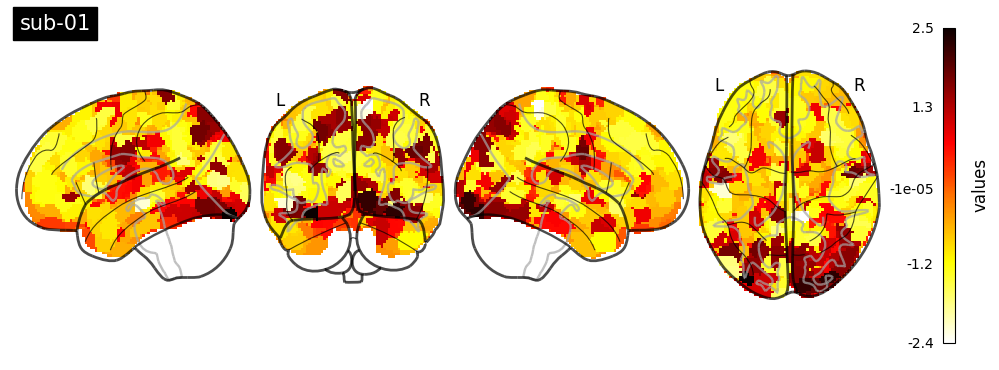

In [ ]:

plot_on_brain(fmri_data[0,:1000].numpy(), 1, args.modality)

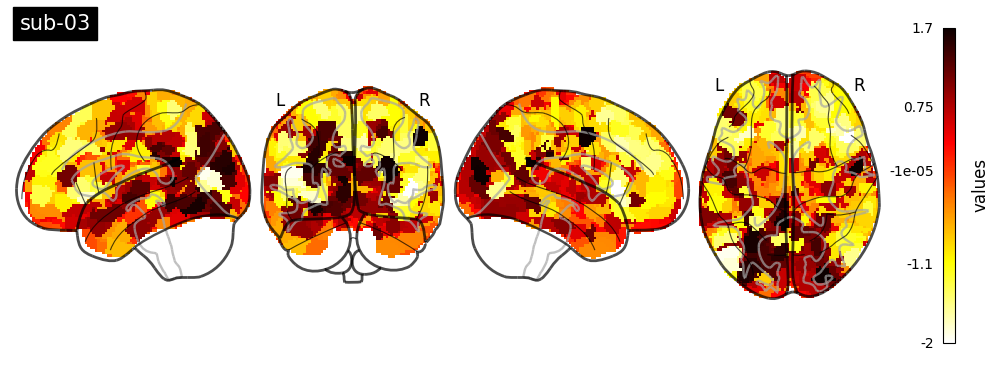

In [40]:
plot_on_brain(fmri_data[0,2000:3000].numpy(), 3, args.modality)

In [13]:
#input, target = next(iter(val_loader))

test_batch = iter(val_dataloader)
input = next(test_batch)[0]
# input = next(test_batch)
# input = next(test_batch)
input['visual'].shape, input['audio'].shape, input['text'] #, target.shape

frames = input['visual'].squeeze(0)
audio = input['audio'].squeeze(0)
text = input['text']

movie type: ood


## Text

In [14]:
text

{'input_ids': tensor([[[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
            0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          101, 102]]]), 'token_type_ids': tensor([[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
          0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [15]:
from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased', do_lower_case=True, padding_side='left')
print(text['input_ids'].squeeze())
print(tokenizer.convert_ids_to_tokens(text['input_ids'].squeeze()))

tensor([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        101, 102])
['[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]',

## Audio

In [15]:
ipd.Audio(audio.numpy(), rate=input['sr'].numpy()[0])

## Video frames

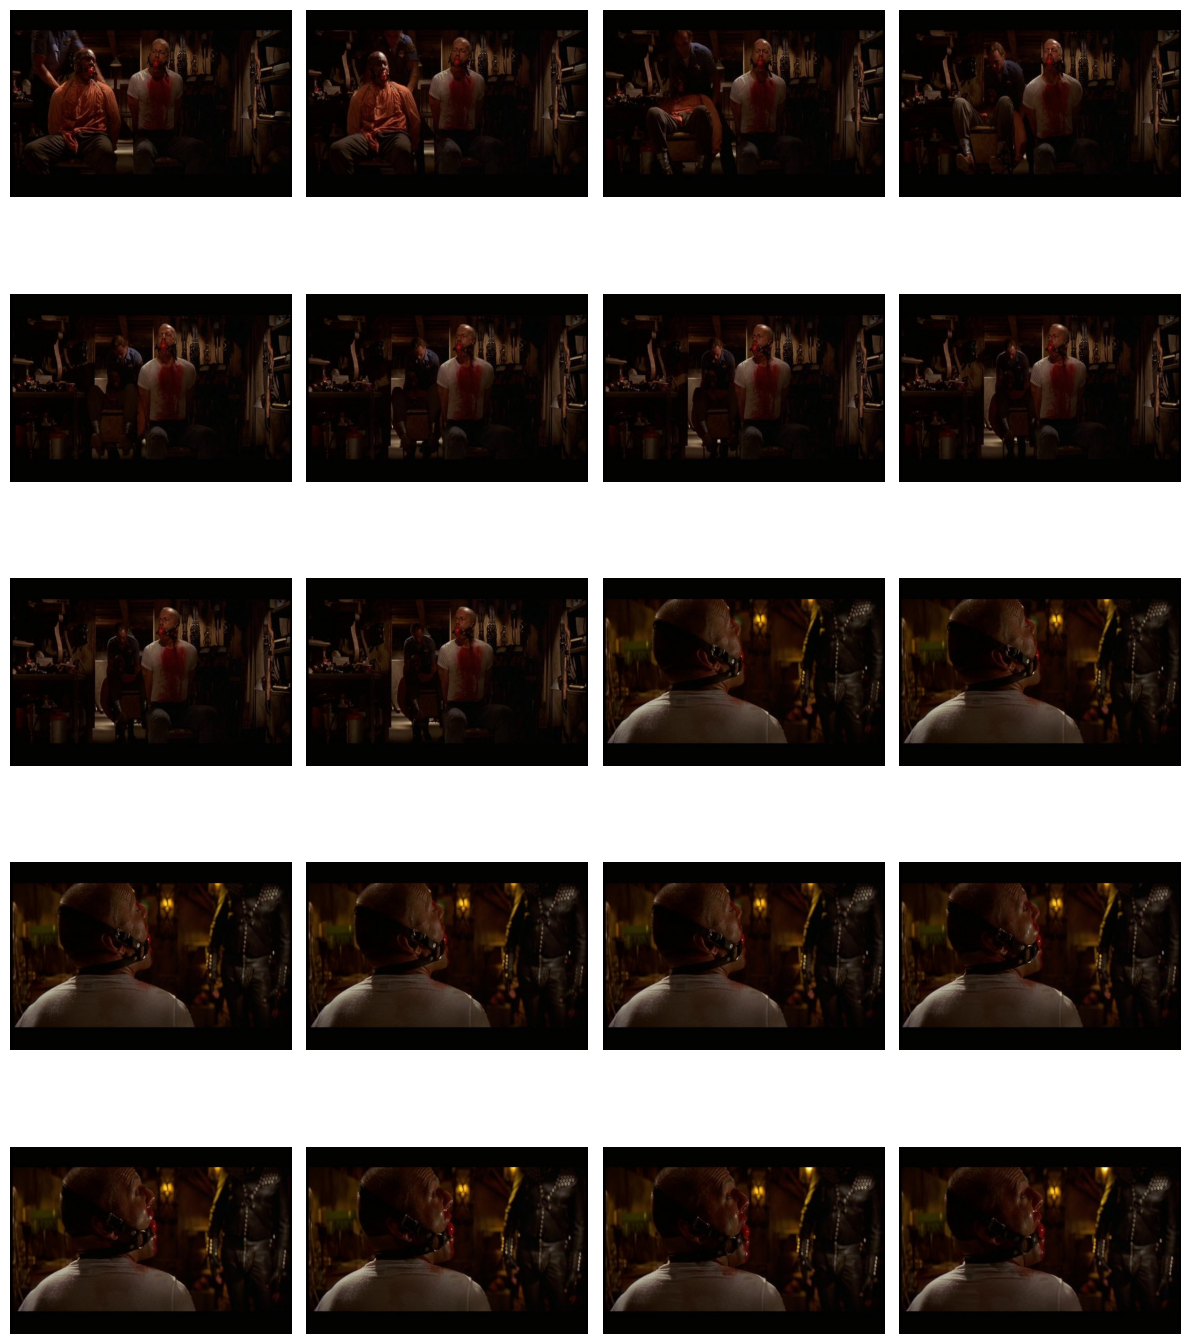

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import torchvision.transforms as transforms

mean = [0.485, 0.456, 0.406]  # Mean used for normalization
std = [0.229, 0.224, 0.225]  # Standard deviation used for normalization

def denormalize(tensor, mean, std):
    """Denormalizes a tensor image."""
    # Create an inverse transform
    inv_normalize = transforms.Normalize(
        mean=[-m / s for m, s in zip(mean, std)],
        std=[1 / s for s in std]
    )

    # Apply the inverse transform
    return inv_normalize(tensor)

# Create a figure with a 5x4 grid of subplots
fig, axes = plt.subplots(nrows=5, ncols=4, figsize=(12, 15))  # Adjust figure size as needed

# Example: Plot random data in each subplot
for i in range(5):
    for j in range(4):
        f = i*4 + j
        axes[i, j].imshow(denormalize(frames[f], mean, std).permute(1,2,0))  # Example random plot
        #axes[i, j].set_title(f"Plot ({i+1},{j+1})")  # Add titles
        axes[i, j].axis('off')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

# for f in range(frames.shape[0]):
#     plt.imshow(frames[f].permute(1,2,0))
#     plt.show()

## OOD dataset

In [4]:
data_root = '/engram/nklab/datasets/'
subject = 1
test_fmri_path = f'{data_root}/algonauts_2025.competitors/fmri/sub-0{subject}/target_sample_number/sub-0{subject}_ood_fmri_samples.npy'
fmri_samples = np.load(test_fmri_path, allow_pickle=True).item()
sessions = list(fmri_samples.keys())

In [5]:
sessions

['chaplin1',
 'chaplin2',
 'mononoke1',
 'mononoke2',
 'passepartout1',
 'passepartout2',
 'planetearth1',
 'planetearth2',
 'pulpfiction1',
 'pulpfiction2',
 'wot1',
 'wot2']

In [8]:
class args_struc():
    def __init__(self):
        self.image_size = 224
        self.data_dir = '/engram/nklab/hossein/recurrent_models/algonauts2025/'
        self.sub = 1
        self.batch_size = 1
        self.backbone_arch = 'dinov2_q'
        self.modality = 'visual audio text'
        self.distributed = 0
        self.num_workers = 0
        self.val_split = 'ood_pulpfiction1'
        self.num_frames = 20
        self.objective = None
        self.text_bb = 'bert'
        self.video_bb = 'None'

args = args_struc()



In [9]:
from datasets.cneuro_data_s import algonauts_dataset

from torchvision import transforms
import torch
from torch.utils.data.distributed import DistributedSampler

class Uint8ToFloat(object):
    """
    Custom transform that converts a torch uint8 tensor to a float tensor
    scaled to [0, 1]. If the input is not a uint8 tensor, it returns the input unchanged.
    """

    def __call__(self, x):
        # Check if x is a tensor and its type is uint8
        if isinstance(x, torch.Tensor) and x.dtype == torch.uint8:
            return x.to(torch.float32) / 255.0
        return x

# old dataloader

# from datasets.cneuro_data_s import fetch_dataloaders
# train_loader, sampler_train, val_loader = fetch_dataloaders(args, train='train')
# test_loader = fetch_dataloaders(args, train='test')


transform_img = transforms.Compose(
    [
        Uint8ToFloat(),
        transforms.Normalize(
            [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        ),  # normalize the images color channels
    ]
)

# if 'finetune' in args.objective:
#     if 'movie' in args.objective:
#         exclude_split = ['s01e', 's02e', 's03e', 's04e', 's06e', 'figures']

# train_dataset = algonauts_dataset(
#     args,
#     exclude_split=args.val_split,
#     transform=transform_img,
# )

val_dataset = algonauts_dataset(
    args,
    include_split=args.val_split,
    transform=transform_img,
)

#print(f"Number of train datapoints: {len(train_dataset)}")
print(f"Number of validation datapoints: {len(val_dataset)}")


if args.distributed == 1:
    sampler_train = DistributedSampler(train_dataset)
    sampler_val = DistributedSampler(val_dataset, shuffle=False)
else:
    #sampler_train = torch.utils.data.RandomSampler(train_dataset)
    sampler_val = torch.utils.data.RandomSampler(train_dataset)
    
# batch_sampler_train = torch.utils.data.BatchSampler(
#     sampler_train, args.batch_size, drop_last=True)

# train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_sampler=batch_sampler_train,
#                     num_workers=args.num_workers) #collate_fn=utils.collate_fn, 
val_dataloader = torch.utils.data.DataLoader(val_dataset, args.batch_size, sampler=sampler_val,
                            drop_last=False, num_workers=args.num_workers) #, collate_fn=utils.collate_fn
    


include split: ood_pulpfiction1


Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.
Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Number of validation datapoints: 468


## Voxel level data

In [2]:
from pathlib import Path
import h5py

In [14]:
# load voxel_level data

fmri = {}
subject = 1
gm = "gm"
for movie_type in ["friends", "movie10"]:
    voxel_timeseries_file = Path(
        f"/engram/nklab/eh2976/cneuromod_extract_tseries/outputs/{movie_type}/Schaefer18_1000Parcels7Networks/sub-0{subject}/func/sub-0{subject}_voxel_timeseries_{gm}.h5"
    )
    voxel_timeseries = h5py.File(voxel_timeseries_file, "r")
    for name in voxel_timeseries["voxel"].keys():
        print(name)
        if name not in fmri:   # initialize dictionary for this name
            fmri[name] = {}
        fmri[name]["voxel"] = voxel_timeseries["voxel"][name]

s01e01a
s01e01b
s01e02a
s01e02b
s01e03a
s01e03b
s01e04a
s01e04b
s01e05a
s01e05b
s01e06a
s01e06b
s01e07a
s01e07b
s01e08a
s01e08b
s01e09a
s01e09b
s01e10a
s01e10b
s01e11a
s01e11b
s01e12a
s01e12b
s01e13a
s01e13b
s01e14a
s01e14b
s01e15a
s01e15b
s01e16a
s01e16b
s01e17a
s01e17b
s01e18a
s01e18b
s01e19a
s01e19b
s01e20a
s01e20b
s01e21a
s01e21b
s01e22a
s01e22b
s01e23a
s01e23b
s01e24a
s01e24b
s02e01a
s02e01b
s02e02a
s02e02b
s02e03a
s02e03b
s02e04a
s02e04b
s02e05a
s02e05b
s02e06a
s02e06b
s02e07a
s02e07b
s02e08a
s02e08b
s02e09a
s02e09b
s02e10a
s02e10b
s02e11a
s02e11b
s02e12a
s02e12b
s02e13a
s02e13b
s02e14a
s02e14b
s02e15a
s02e15b
s02e16a
s02e16b
s02e17a
s02e17b
s02e18a
s02e18b
s02e19a
s02e19b
s02e20a
s02e20b
s02e21a
s02e21b
s02e22a
s02e22b
s02e23a
s02e23b
s02e24a
s02e24b
s03e01a
s03e01b
s03e02a
s03e02b
s03e03a
s03e03b
s03e04a
s03e04b
s03e05a
s03e05b
s03e06a
s03e06b
s03e07a
s03e07b
s03e08a
s03e08b
s03e09a
s03e09b
s03e10a
s03e10b
s03e11a
s03e11b
s03e12a
s03e12b
s03e13a
s03e13b
s03e14a
s03e14b
s03e15a


In [16]:
fmri

{'s01e01a': {'voxel': <HDF5 dataset "s01e01a": shape (592, 172218), type "<f8">},
 's01e01b': {'voxel': <HDF5 dataset "s01e01b": shape (592, 172218), type "<f8">},
 's01e02a': {'voxel': <HDF5 dataset "s01e02a": shape (482, 172218), type "<f8">},
 's01e02b': {'voxel': <HDF5 dataset "s01e02b": shape (482, 172218), type "<f8">},
 's01e03a': {'voxel': <HDF5 dataset "s01e03a": shape (472, 172218), type "<f8">},
 's01e03b': {'voxel': <HDF5 dataset "s01e03b": shape (472, 172218), type "<f8">},
 's01e04a': {'voxel': <HDF5 dataset "s01e04a": shape (503, 172218), type "<f8">},
 's01e04b': {'voxel': <HDF5 dataset "s01e04b": shape (503, 172218), type "<f8">},
 's01e05a': {'voxel': <HDF5 dataset "s01e05a": shape (468, 172218), type "<f8">},
 's01e05b': {'voxel': <HDF5 dataset "s01e05b": shape (468, 172218), type "<f8">},
 's01e06a': {'voxel': <HDF5 dataset "s01e06a": shape (488, 172218), type "<f8">},
 's01e06b': {'voxel': <HDF5 dataset "s01e06b": shape (488, 172218), type "<f8">},
 's01e07a': {'vo

In [ ]:
172218/

In [9]:
import numpy as np

fmri = {}

root_data_dir = "/engram/nklab/datasets/"
subject = 1
### Load the fMRI responses for Friends ###
# Data directory
fmri_file = f"sub-0{subject}_task-friends_space-MNI152NLin2009cAsym_atlas-Schaefer18_parcel-1000Par7Net_desc-s123456_bold.h5"
fmri_dir = os.path.join(
    root_data_dir,
    "algonauts_2025.competitors",
    "fmri",
    f"sub-0{subject}",
    "func",
    fmri_file,
)
# Load the the fMRI responses
fmri_friends = h5py.File(fmri_dir, "r")
for key, val in fmri_friends.items():
    fmri[str(key[13:])] = {"parcel": val[:].astype(np.float32)}
#del fmri_friends

In [18]:
fmri['s01e02a']['voxel'].shape

(482, 172218)